In [78]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [81]:
import torch
from scripts.arraySpec import ArraySpec
from scripts.batchFactory import generateBatch
from ui.export_target import load_target_from_pt

# Setup device and precision
dtype = torch.float32
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")


# spec = ArraySpec(failRate=0.05, positionJitterSTD=0.01, phaseJitterSTD=0.1)
spec = ArraySpec(geometry="UCA", allowedAspectRatio=[1], allowedElementCount=[400000])
batch = generateBatch(spec, batchSize=2, device=device, dtype=dtype, weightsType="random")
target = load_target_from_pt("target_spec.pt")
hotspot = target.hotspotCoordinates[0].to(device)

batch2 = generateBatch(
    spec, batchSize=2, device=device, dtype=dtype, weightsType="directed", targetLLA=hotspot
)

# Output test values
print("--- Antenna Batch Generated Successfully ---")
print(f"Elements in Array: {batch.N}")
print(f"Device           : {batch.device}")
print(f"Dtype            : {batch.dtype}")
print(f"Wavelength       : {batch.wavelength:.5f}m")
print(f"Local Positions  : {batch.elementLocalPosition.shape} | {batch.elementLocalPosition.dtype}")
print(f"Base Weights     : {batch.weights.shape} | {batch.weights.dtype}")
print(f"Effective Weights: {batch.effective_weights().shape} | {batch.effective_weights().dtype}")
print(f"Gain             : {batch.gain.shape} | {batch.gain.dtype}")
print(f"LLA [Lat,Lon,Alt]: {batch.LLAPosition.shape} | {batch.LLAPosition.dtype}")
print(f"ECEF      [X,Y,Z]: {batch.ECEFPosition.shape} | {batch.ECEFPosition.dtype}")

--- Antenna Batch Generated Successfully ---
Elements in Array: 314701
Device           : mps:0
Dtype            : torch.float32
Wavelength       : 0.00999m
Local Positions  : torch.Size([2, 3, 314701]) | torch.float32
Base Weights     : torch.Size([2, 314701]) | torch.complex64
Effective Weights: torch.Size([2, 314701]) | torch.complex64
Gain             : torch.Size([2]) | torch.float32
LLA [Lat,Lon,Alt]: torch.Size([2, 3]) | torch.float32
ECEF      [X,Y,Z]: torch.Size([2, 3]) | torch.float32


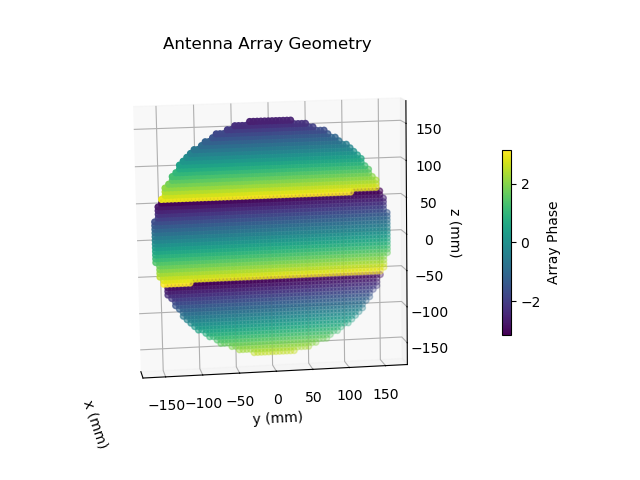

In [74]:
from scripts.plots import plotArrayGeometry

plotArrayGeometry(batch2)

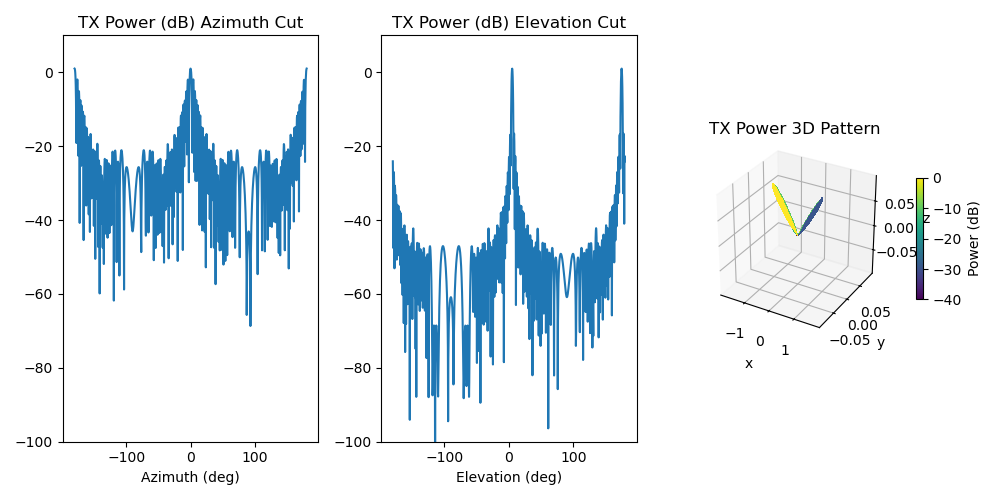

In [75]:
from scripts.plots import plotArrayFactor

plotArrayFactor(batch2, projection=None, xProjectionScale=20)

In [ ]:
from models.reward import batchScore

score = batchScore(batch, target)
print(score)
score = batchScore(batch2, target)
print(score)

RuntimeError: Invalid buffer size: 23.64 GiB